In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_wine

In [5]:

(X,y) = load_wine(return_X_y = True, as_frame = True)
Xy = pd.concat([X, y], axis=1)
(n, p) = X.shape 
K = y.unique().size 
print('n=', n, ', p=', p, ', K=', K)
X.head()

n= 178 , p= 13 , K= 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


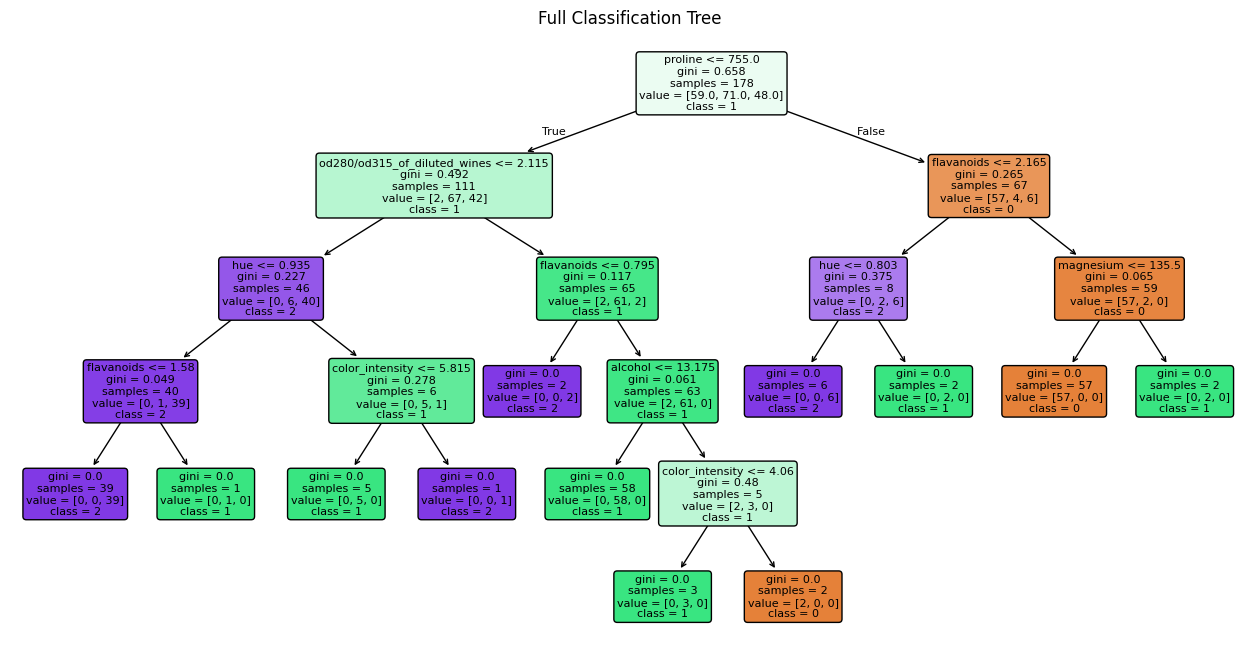

In [8]:
full_tree = DecisionTreeClassifier(random_state=20)
full_tree.fit(X, y)

plt.figure(figsize=(16, 8))
plot_tree(
    full_tree,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Full Classification Tree")
plt.show()

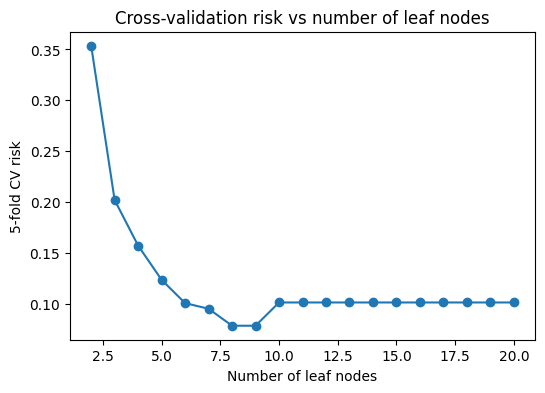

Best number of leaf nodes = 8
Minimum CV risk = 0.07841269841269849


In [9]:
leaf_grid = range(2, 21)
cv_risks = []

for L in leaf_grid:
    tree = DecisionTreeClassifier(max_leaf_nodes=L, random_state=12)
    scores = cross_val_score(tree, X, y, cv=5, scoring='accuracy')
    risk = 1 - scores.mean()
    cv_risks.append(risk)

plt.figure(figsize=(6,4))
plt.plot(list(leaf_grid), cv_risks, marker='o')
plt.xlabel("Number of leaf nodes")
plt.ylabel("5-fold CV risk")
plt.title("Cross-validation risk vs number of leaf nodes")
plt.show()

best_leaf = leaf_grid[np.argmin(cv_risks)]
print("Best number of leaf nodes =", best_leaf)
print("Minimum CV risk =", np.min(cv_risks))

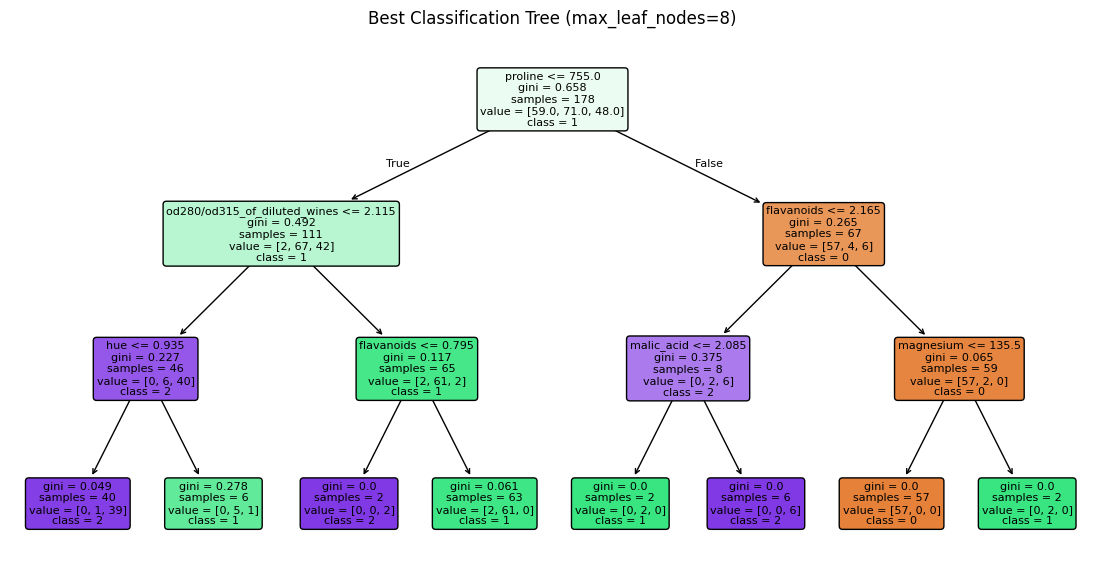

In [10]:
best_tree = DecisionTreeClassifier(max_leaf_nodes=best_leaf, random_state=12)
best_tree.fit(X, y)

plt.figure(figsize=(14, 7))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title(f"Best Classification Tree (max_leaf_nodes={best_leaf})")
plt.show()

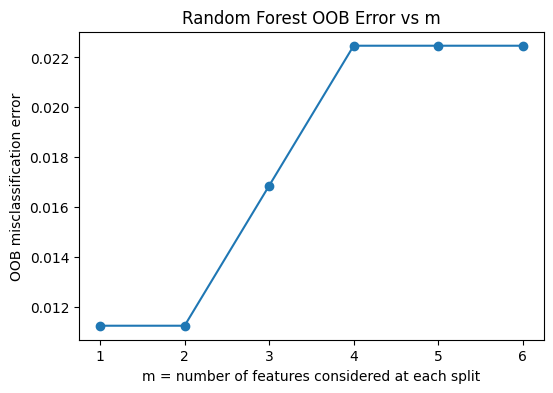

Best m = 1
Minimum OOB error = 0.011235955056179803


In [11]:
m_grid = range(1, 7)
oob_errors = []

for m in m_grid:
    rf = RandomForestClassifier(
        n_estimators=500,
        max_features=m,
        oob_score=True,
        bootstrap=True,
        random_state=12
    )
    rf.fit(X, y)
    oob_error = 1 - rf.oob_score_
    oob_errors.append(oob_error)

plt.figure(figsize=(6,4))
plt.plot(list(m_grid), oob_errors, marker='o')
plt.xlabel("m = number of features considered at each split")
plt.ylabel("OOB misclassification error")
plt.title("Random Forest OOB Error vs m")
plt.show()

best_m = m_grid[np.argmin(oob_errors)]
print("Best m =", best_m)
print("Minimum OOB error =", np.min(oob_errors))

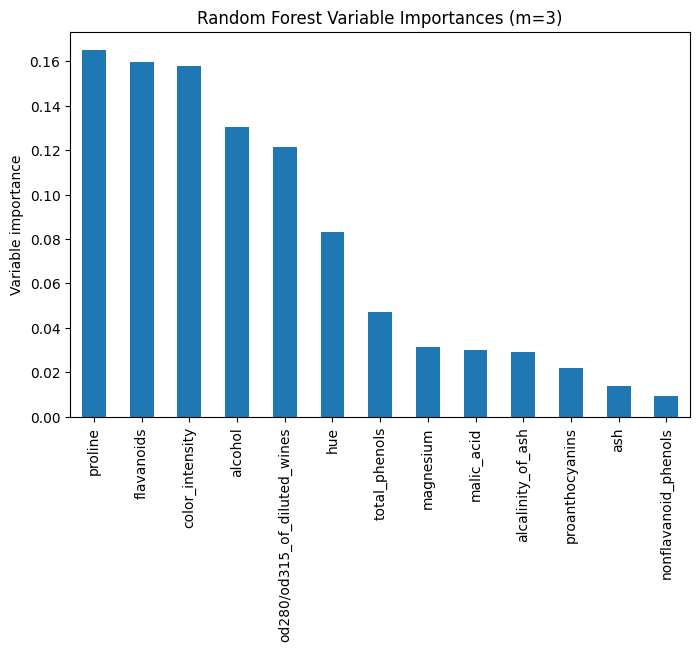

proline                         0.164999
flavanoids                      0.159713
color_intensity                 0.157916
alcohol                         0.130434
od280/od315_of_diluted_wines    0.121200
hue                             0.083146
total_phenols                   0.047375
magnesium                       0.031219
malic_acid                      0.029927
alcalinity_of_ash               0.029012
proanthocyanins                 0.021893
ash                             0.013759
nonflavanoid_phenols            0.009410
dtype: float64


In [12]:
rf_m3 = RandomForestClassifier(
    n_estimators=500,
    max_features=3,
    oob_score=True,
    bootstrap=True,
    random_state=12
)
rf_m3.fit(X, y)

importances = pd.Series(rf_m3.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind='bar')
plt.ylabel("Variable importance")
plt.title("Random Forest Variable Importances (m=3)")
plt.show()

print(importances)